# 23. Итоговое сравнение всех моделей

Ноутбук не переобучает модели. Он читает результаты, созданные предыдущими этапами,
приводит их к общей длинной таблице и строит сопоставимые графики. Метрики разных
evaluation regimes показываются отдельно, чтобы не создавать ложный рейтинг.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Неверный путь.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from project_paths import *
ensure_project_directories()

print("Project root:", PROJECT_ROOT)

Project root: D:\Users\user\Desktop\DS_XRD_project


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = FIGURES_DIR / "23_model_comparison"
TAB_DIR = TABLES_DIR / "23_model_comparison"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

specs = [
    ("FT V2 replay", "ft_v2_cv_summary.csv", "after_ft", "historical_combined"),
    ("Real-only V2", "real_only_v2_cv_summary.csv", "real_only", "historical_combined"),
    ("Staged V3", "ft_v3_staged_cv_summary.csv", "after_ft", "historical_combined"),
    ("RRUFF-only", "ft_rruff_only_cv_summary.csv", "after_source_ft", "rruff_only"),
    ("opXRD-only", "ft_opxrd_only_cv_summary.csv", "after_source_ft", "opxrd_only"),
    ("Combined no replay", "ft_combined_no_replay_control_cv_summary.csv", "after_combined_ft", "historical_combined"),
    ("RRUFF-only + SG", "ft_rruff_only_with_rruff_sg_cv_summary.csv", "after_source_ft", "rruff_sg"),
    ("Combined + SG", "ft_combined_no_replay_control_with_rruff_sg_cv_summary.csv", "after_combined_ft", "combined_sg"),
    ("Real-only + SG", "real_only_v2_with_rruff_sg_cv_summary.csv", "real_only", "combined_sg"),
]

rows = []
for model, filename, value_col, regime in specs:
    path = OUTPUTS_DIR / filename
    if not path.exists():
        print("Missing; run the corresponding notebook:", filename)
        continue
    frame = pd.read_csv(path)
    if "scope" in frame.columns and regime.startswith("combined"):
        frame = frame[frame["scope"].eq("combined")]
    if value_col not in frame.columns and model == "Staged V3":
        value_col = "staged_ft"
    for _, row in frame.iterrows():
        rows.append({"model": model, "regime": regime, "metric": row["metric"],
                     "value": pd.to_numeric(row.get(value_col), errors="coerce"),
                     "std": pd.to_numeric(row.get("std"), errors="coerce")})
comparison = pd.DataFrame(rows)
comparison.to_csv(TAB_DIR / "all_models_long.csv", index=False)
display(comparison.head(20))

,model,regime,metric,value,std
0,FT V2 replay,historical_combined,sys_acc,0.630000,0.022000
1,FT V2 replay,historical_combined,sg_acc,0.509000,0.212000
2,FT V2 replay,historical_combined,sg_top5,0.676000,0.238000
3,FT V2 replay,historical_combined,el_f1_micro,0.501000,0.048000
4,FT V2 replay,historical_combined,el_exact,0.179000,0.041000
5,FT V2 replay,historical_combined,mae_a,2.662000,0.170000
6,FT V2 replay,historical_combined,mae_a_med,1.523000,0.138000
7,FT V2 replay,historical_combined,mae_ang,4.574000,0.133000
8,Real-only V2,historical_combined,sys_acc,0.567060,0.025899
9,Real-only V2,historical_combined,sg_acc,0.365316,0.210739


## Классификационные метрики внутри каждого режима

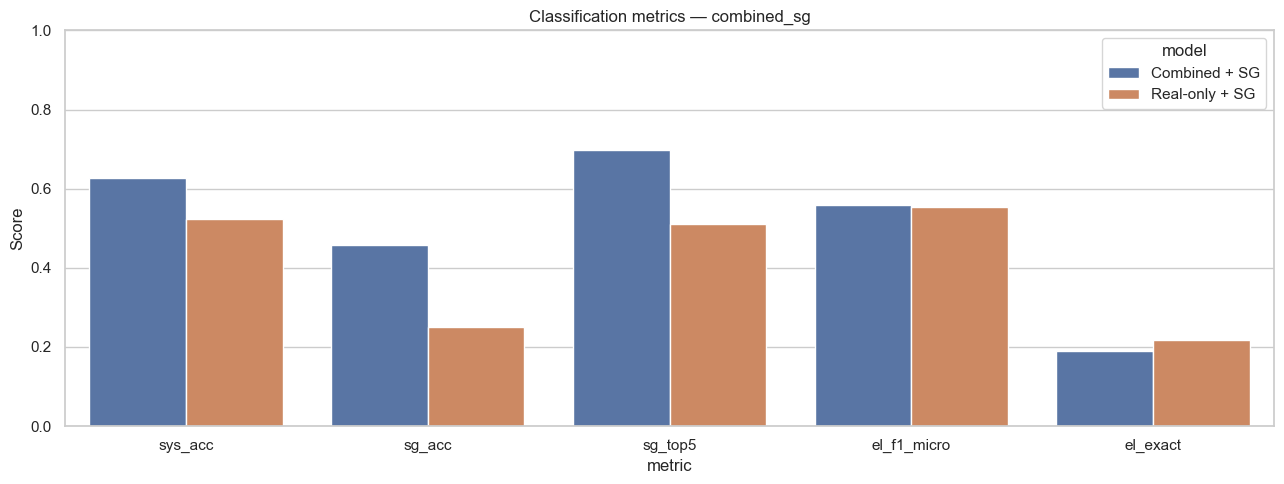

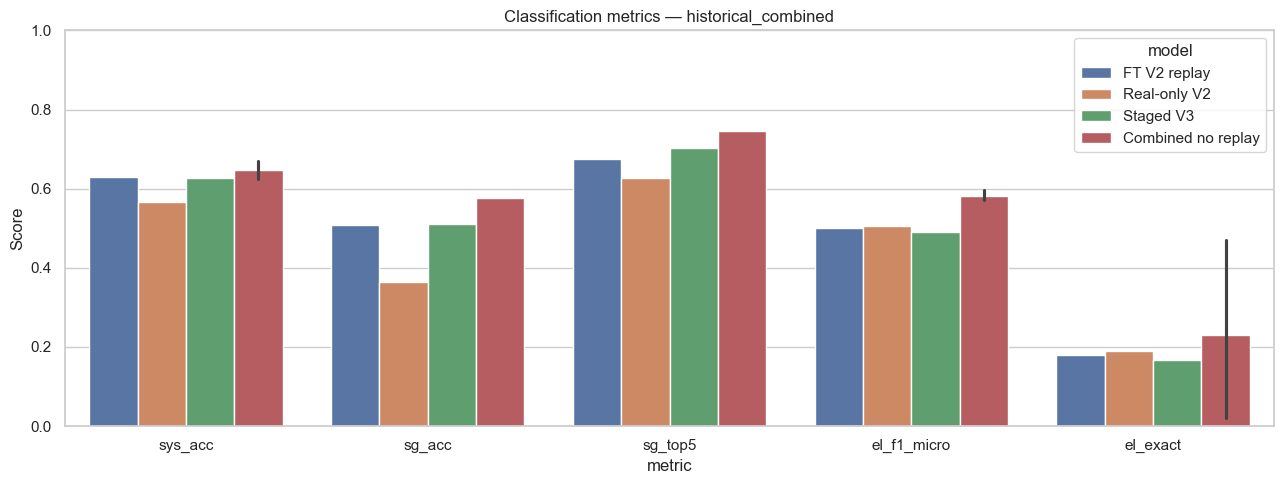

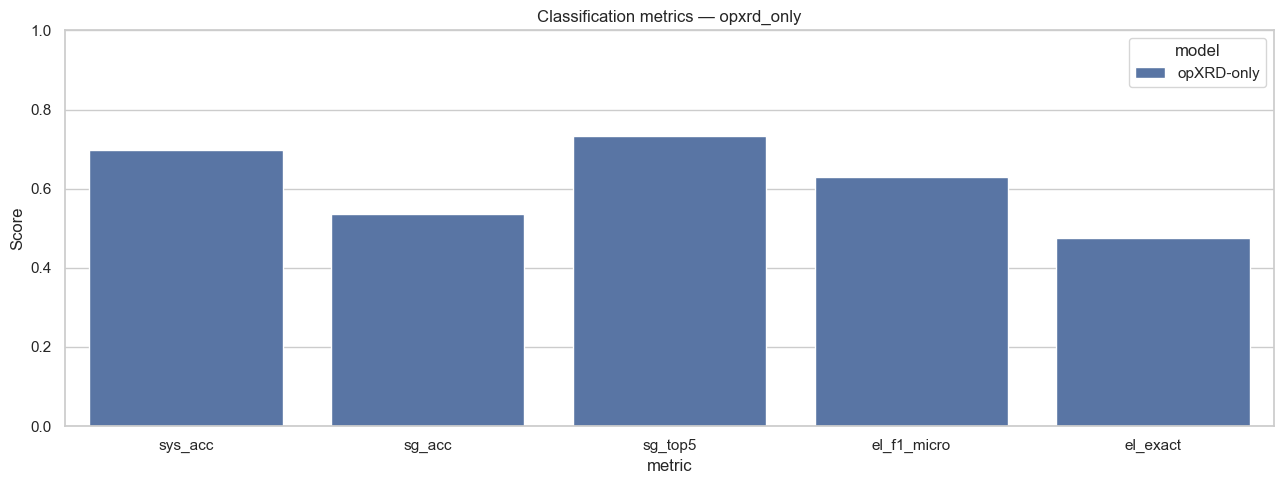

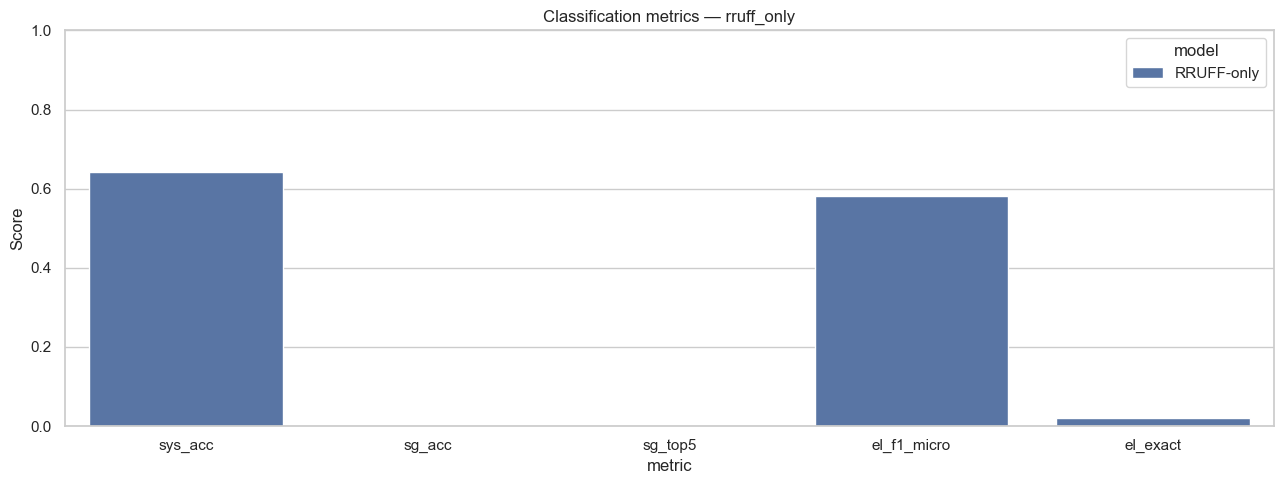

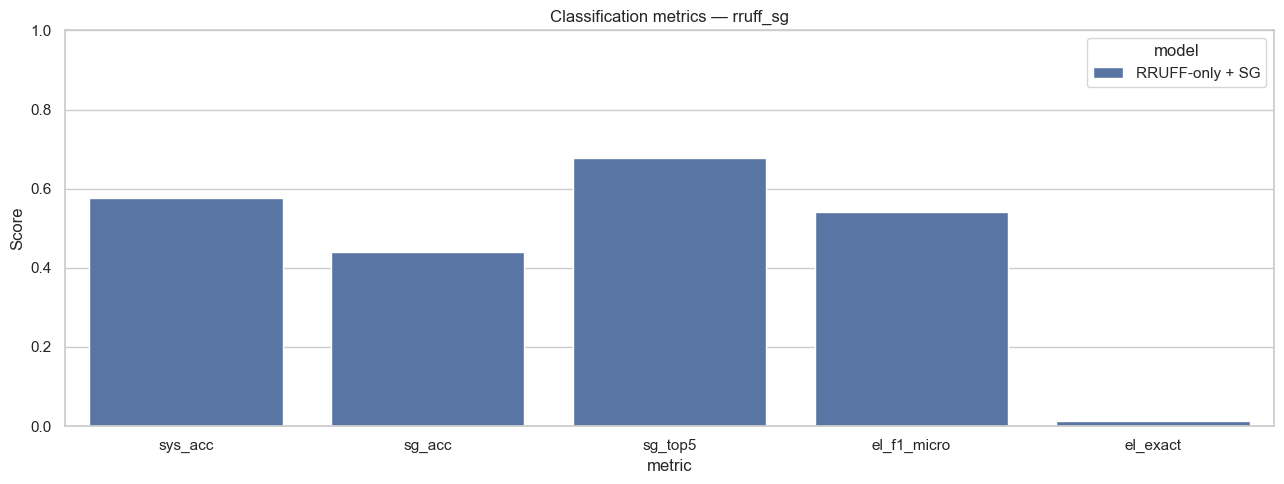

In [3]:
class_metrics = ["sys_acc", "sg_acc", "sg_top5", "el_f1_micro", "el_exact"]
for regime, frame in comparison[comparison.metric.isin(class_metrics)].groupby("regime"):
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.barplot(data=frame, x="metric", y="value", hue="model", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title(f"Classification metrics — {regime}")
    ax.set_ylabel("Score")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"classification_{regime}.png", dpi=170, bbox_inches="tight")
    plt.show()

## Ошибки параметров решётки

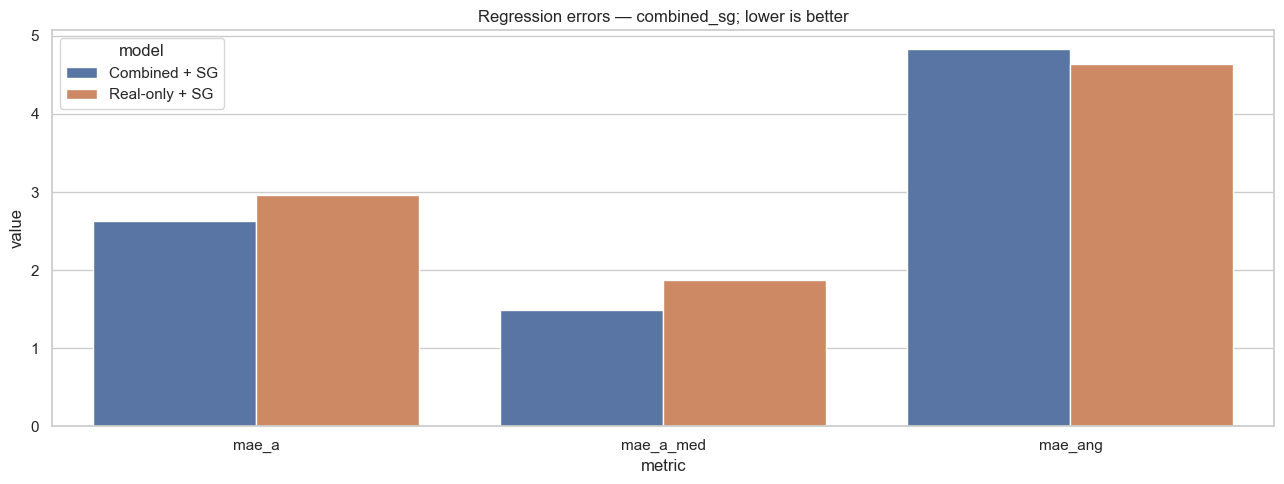

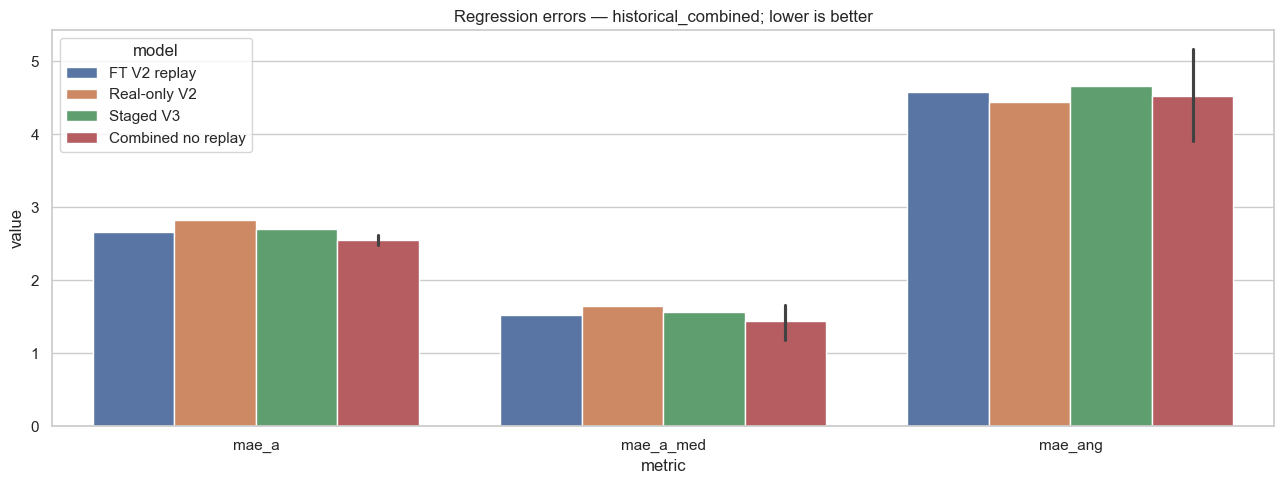

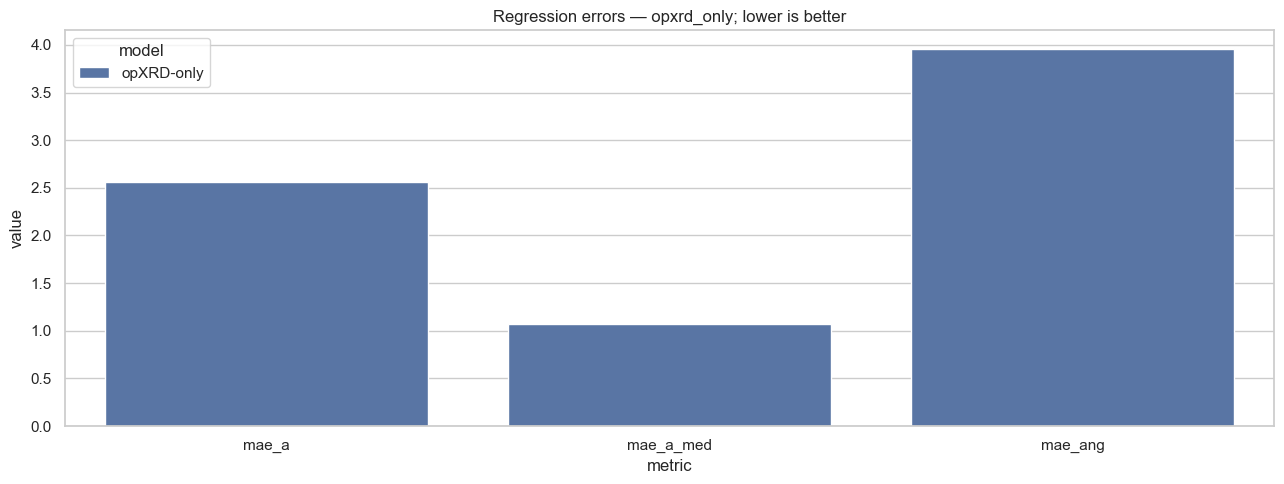

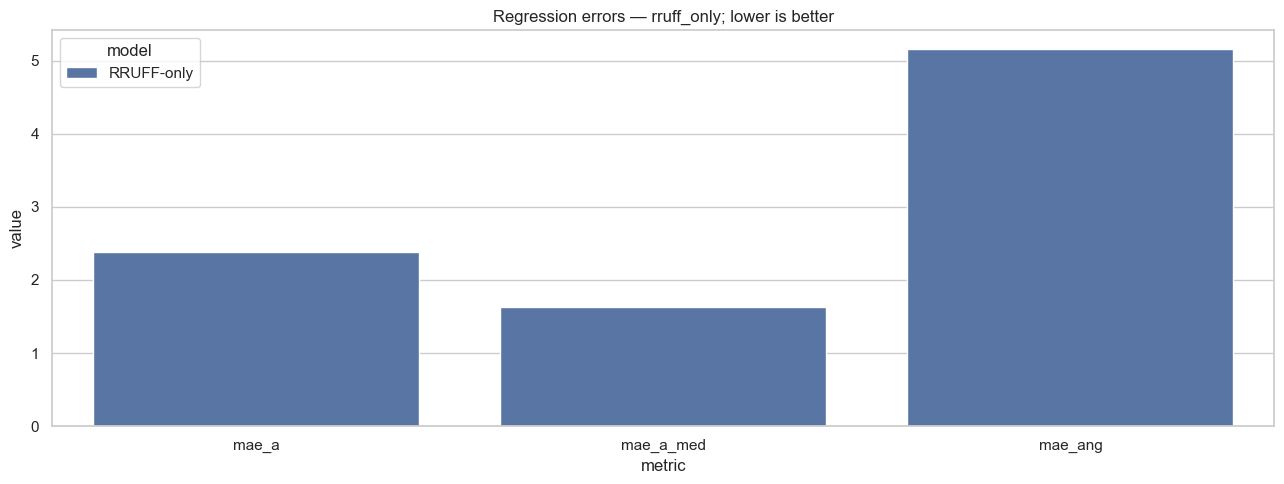

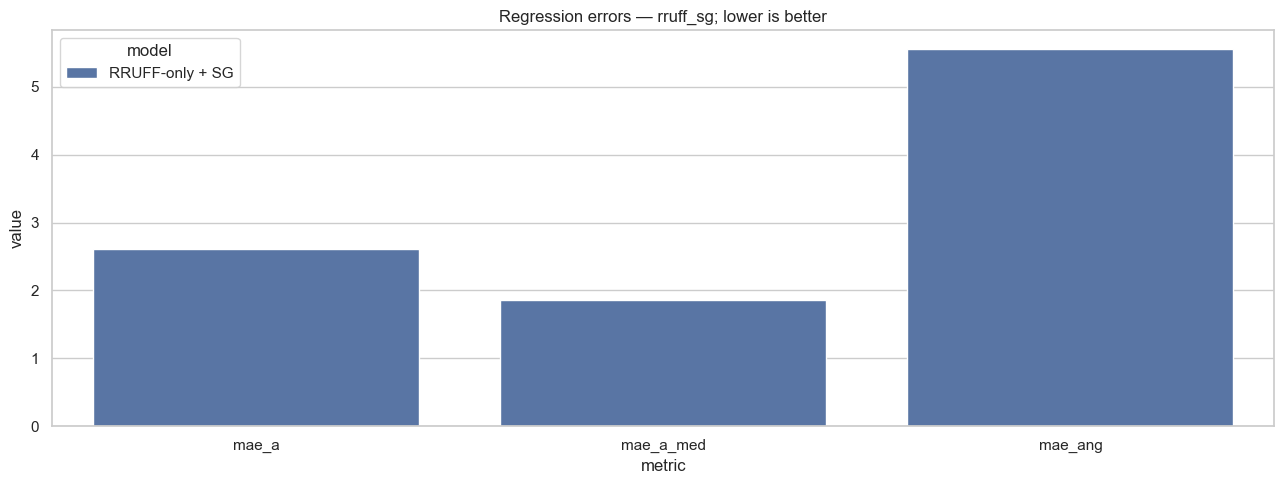

In [4]:
error_metrics = ["mae_a", "mae_a_med", "mae_ang", "vol_mae", "vol_rel_med"]
for regime, frame in comparison[comparison.metric.isin(error_metrics)].groupby("regime"):
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.barplot(data=frame, x="metric", y="value", hue="model", ax=ax)
    ax.set_title(f"Regression errors — {regime}; lower is better")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"regression_{regime}.png", dpi=170, bbox_inches="tight")
    plt.show()

## Парная single-phase абляция

,eval_set,scope,metric,single_phase_ft,all_real_ft,difference_single_minus_all,std_paired_difference,folds
30,single_phase,combined,el_exact,0.006648,0.008124,-0.001476,0.001808,5
31,single_phase,combined,el_f1_micro,0.546523,0.524236,0.022287,0.006832,5
32,single_phase,combined,mae_a,3.020258,3.048718,-0.028460,0.059272,5
33,single_phase,combined,mae_a_med,1.909688,1.918882,-0.009194,0.076800,5
34,single_phase,combined,mae_ang,5.231820,5.276579,-0.044760,0.076608,5
35,single_phase,combined,mae_b,3.063050,3.088925,-0.025875,0.067912,5
36,single_phase,combined,mae_c,4.000873,4.030827,-0.029954,0.120511,5
37,single_phase,combined,mae_vol,1269.666442,1275.709261,-6.042819,20.666789,5
38,single_phase,combined,mape_a_med,25.086398,24.965869,0.120529,0.916039,5
39,single_phase,combined,mape_b_med,22.936727,22.504196,0.432531,0.693019,5


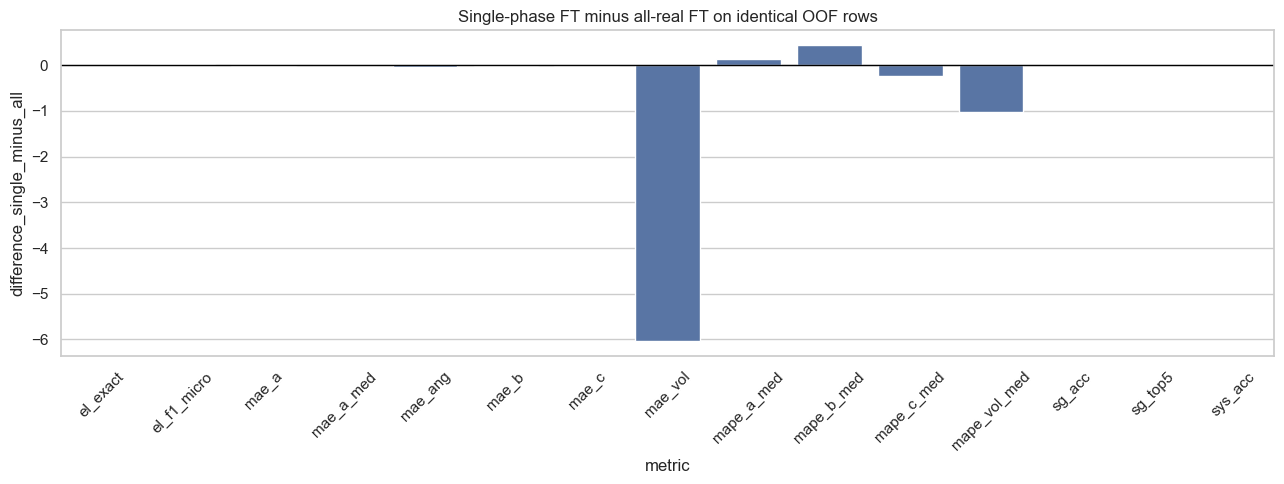

In [5]:
paired_path = OUTPUTS_DIR / "ft_single_phase_ablation_with_rruff_sg_paired_summary.csv"
if paired_path.exists():
    paired = pd.read_csv(paired_path)
    main = paired[(paired["eval_set"] == "single_phase") & (paired["scope"] == "combined")]
    display(main)
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.barplot(data=main, x="metric", y="difference_single_minus_all", ax=ax)
    ax.axhline(0, color="black", lw=1)
    ax.set_title("Single-phase FT minus all-real FT on identical OOF rows")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "single_phase_paired_difference.png", dpi=170, bbox_inches="tight")
    plt.show()

## Итоговый вывод

Основной финальный checkpoint —
`ft_combined_no_replay_control_with_rruff_sg_final.pt`. Source-only и исторические
результаты показываются как отдельные эксперименты, а не как напрямую сопоставимый
единый leaderboard.